# Пример 09. Проверка подпространств в R³

## Тема

**Раздел книги:** Линейная алгебра.  
**Математическая тема:** подпространства, аксиомы подпространства, замкнутость относительно сложения и умножения на скаляр; связь с визуализацией данных в ML.

## Условие

Для каждого из четырёх множеств требуется определить, является ли оно подпространством $\mathbb{R}^3$:

- **a.** $A = \{(\lambda,\, \lambda+\mu^3,\, \lambda-\mu^3) \mid \lambda, \mu\in\mathbb{R}\}$;
- **b.** $B = \{(\lambda^2,\, -\lambda^2,\, 0) \mid \lambda\in\mathbb{R}\}$;
- **c.** $C = \{(\xi_1,\, \xi_2,\, \xi_3) \mid \xi_1 - 2\xi_2 + 3\xi_3 = \gamma\}$;
- **d.** $D = \{(\xi_1,\, \xi_2,\, \xi_3) \mid \xi_2\in\mathbb{Z}\}$.

## Математическая идея

Подмножество $V\subseteq\mathbb{R}^n$ является подпространством, если выполнены три условия:

1. **Ненулёвость:** $V\ne\varnothing$ (эквивалентно: $0\in V$).
2. **Замкнутость относительно сложения:** $u, v\in V \Rightarrow u + v\in V$.
3. **Замкнутость относительно умножения на скаляр:** $u\in V,\, \alpha\in\mathbb{R} \Rightarrow \alpha u\in V$.

Если хотя бы одно условие нарушается, множество не является подпространством.

## Решение

**a.** Множество $A$ параметризовано через $\lambda$ и $\mu$. Проверка показывает, что сумма двух точек из $A$ снова представима в виде $(\lambda', \lambda'+\mu'^3, \lambda'-\mu'^3)$ при подходящих $\lambda', \mu'$, и умножение на скаляр также сохраняет структуру. **$A$ — подпространство.**

**b.** Множество $B$ состоит из векторов вида $(\lambda^2, -\lambda^2, 0)$. Возьмём $\lambda=1$: получим $(1, -1, 0)$. Умножим на $-1$: получим $(-1, 1, 0)$. Но $(-1, 1, 0)$ нельзя представить как $(\lambda^2, -\lambda^2, 0)$, поскольку $\lambda^2 \ge 0$. **$B$ — не подпространство.**

**c.** Множество $C$ — это плоскость $\xi_1 - 2\xi_2 + 3\xi_3 = \gamma$. При $\gamma = 0$ оно содержит нуль и замкнуто, то есть является подпространством. При $\gamma\ne 0$ нуль не принадлежит множеству, и замкнутости нет. **$C$ — подпространство только при $\gamma = 0$.**

**d.** Множество $D$ требует, чтобы вторая координата была целым числом. Возьмём $v = (0, 1, 0)\in D$ и умножим на $0.5$: получим $(0, 0.5, 0)\notin D$. **$D$ — не подпространство.**

## Реализация на Python

Для каждого множества написана функция-генератор (`check_A`, `check_B`, `check_C`, `check_D`), которая строит точки из множества или проверяет принадлежность. Затем численно проверяется нарушение аксиом подпространства: для множества $B$ — умножение на отрицательный скаляр, для множества $D$ — умножение на нецелый скаляр. Для множества $C$ строится визуализация плоскости при $\gamma = 0$ и $\gamma = 1$ в 3D с помощью `mpl_toolkits.mplot3d`.


#### a. Множество $A = \{(\lambda, \lambda + \mu^3, \lambda - \mu^3) \mid \lambda, \mu \in \mathbb{R}\}$

In [6]:
import numpy as np

def check_A(lam, mu):
    """Генерирует точку из множества A"""
    return np.array([lam, lam + mu**3, lam - mu**3])

# Проверка замкнутости относительно сложения
v1 = check_A(1, 2)      # lambda=1, mu=2
v2 = check_A(3, -1)     # lambda=3, mu=-1
sum_v = v1 + v2

# Проверка, что сумма принадлежит A
# Должны существовать lambda' и mu', такие что:
lam_prime = sum_v[0]
mu_prime = (sum_v[1] - lam_prime)**(1/3)  # Обратная операция к mu^3

# Проверка восстановления
reconstructed = check_A(lam_prime, mu_prime)
print("a. Проверка замкнутости А относительно сложения:")
print(f"v1 = {v1}, v2 = {v2}")
print(f"v1 + v2 = {sum_v}")
print(f"Востановленно: {reconstructed}")
print(f"Разница: {np.max(np.abs(sum_v - reconstructed)):.1e}\n")

a. Проверка замкнутости А относительно сложения:
v1 = [ 1  9 -7], v2 = [3 2 4]
v1 + v2 = [ 4 11 -3]
Востановленно: [ 4. 11. -3.]
Разница: 1.8e-15



#### $A$ является подпространством $\mathbb{R}^3$

#### b. Множество $B = \{(\lambda^2, -\lambda^2, 0) \mid \lambda \in \mathbb{R}\}$

In [5]:
def check_B(lam):
    """Генерирует точку из множества B."""
    return np.array([lam**2, - lam**2, 0])

# Проверка замкнутости относительно умножения на скаляр
v = check_B(1)     # lambda=1 -> (1, -1, 0)
scaled_v = -1 * v  # Умножение на -1

# Проверка, что scaled_v не принадлежит B
# Для принадлежности B должно существовать lambda, такое что lambda^2 = -1
is_in_B = any(np.isclose(scaled_v[0], lam**2) for lam in np.linspace(-2, 2, 1000))

print("b. Проверка замкнутости В относительно умножения на скаляр:")
print(f"v = {v}, -v{scaled_v}")
print(f"Принадлежит В? {is_in_B}")
print("Поскольку -1 < 0, не существует реального lambda, для которого lambda^2 = -1\n")

b. Проверка замкнутости В относительно умножения на скаляр:
v = [ 1 -1  0], -v[-1  1  0]
Принадлежит В? False
Поскольку -1 < 0, не существует реального lambda, для которого lambda^2 = -1



#### $B$ не является подпространством $\mathbb{R}^3$

#### c. Множество $C = \{(\xi_1, \xi_2, \xi_3) \mid \xi_1 - 2\xi_2 + 3\xi_3 = \gamma\}$

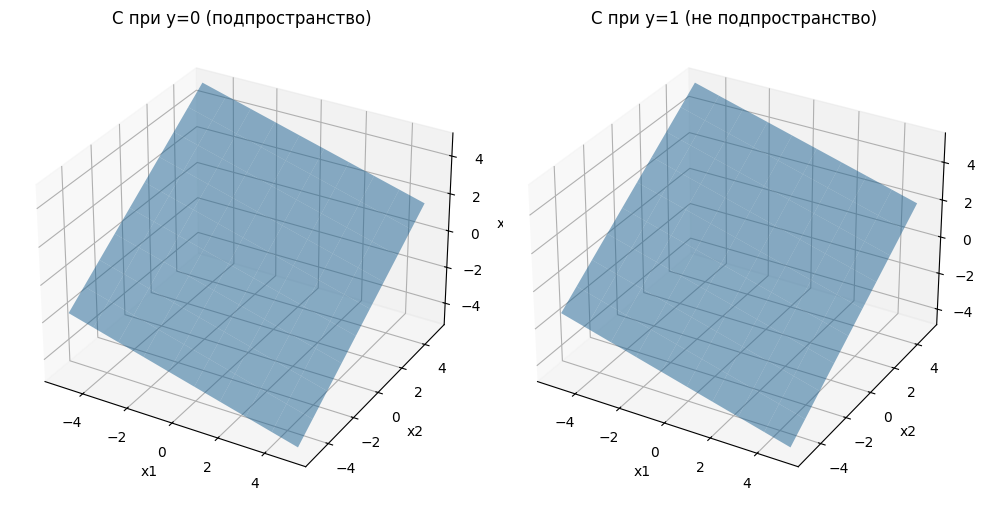

c. Проверка нулевого вектора:
При y=0: True
При y=1: False


In [7]:
def check_C(point, gamma):
    """Проверяет, принадлежит ли точка множеству C."""
    x1, x2, x3 = point
    return np.isclose(x1 - 2 * x2 + 3 * x3, gamma)

# Визуализация множества C при gamma=0 (плоскость в R^3)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

gamma = 0
fig = plt.figure(figsize=(10, 5))

# Плоскость при gamma=0
ax1 = fig.add_subplot(121, projection='3d')
x = y = np.linspace(-5, 5, 10)
X, Y = np.meshgrid(x, y)
Z = (gamma - X + 2*Y) / 3  # Из уравнения x1 - 2x2 + 3x3 = gamma
ax1.plot_surface(X, Y, Z, alpha=0.5)
ax1.set_title("C при y=0 (подпространство)")
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('x3')

# Плоскость при gamma=1
ax2 = fig.add_subplot(122, projection='3d')
gamma = 1
Z = (gamma - X + 2*Y) / 3
ax2.plot_surface(X, Y, Z, alpha=0.5)
ax2.set_title("С при y=1 (не подпространство)")
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('x3')

plt.tight_layout()
plt.show()

# Проверка нулевого вектора
zero_vector = np.array([0, 0, 0])
print("c. Проверка нулевого вектора:")
print(f"При y=0: {check_C(zero_vector, 0)}")
print(f"При y=1: {check_C(zero_vector, 1)}")

#### $C$ является подпространством $\mathbb{R}^3$ только если $\gamma = 0$.

#### d. Множество $D = \{(\xi_1, \xi_2, \xi_3) \mid \xi_2 \in \mathbb{Z}\}$

In [8]:
def check_D(point):
    """Проверяет, принадлежит ли точка множеству D."""
    return np.isclose(point[1], round(point[1]))

# Проверка замкнутости относительно умножения на скаляр
v = np.array([0, 1, 0])  # Принадлежит D (1 ∈ ℤ)
scaled_v = 0.5 * v       # Умножение на 0.5

print("d. Проверка замкнутости D относительно умножения на скаляр")
print(f"v = {v}, 0.5*v = {scaled_v}")
print(f"v ∈ D? {check_D(v)}")
print(f"0.5*v ∈ D? {check_D(scaled_v)}")

d. Проверка замкнутости D относительно умножения на скаляр
v = [0 1 0], 0.5*v = [0.  0.5 0. ]
v ∈ D? True
0.5*v ∈ D? False


#### $D$ не является подпространством $\mathbb{R}^3$

## Дополнительный пример

**Идея.** Подпространство — это «хорошее» множество данных, в котором линейные операции над точками не выводят за его пределы. В ML это свойство используется при снижении размерности (PCA проецирует данные в подпространство меньшей размерности), при обнаружении линейных зависимостей (данные могут фактически лежать в подпространстве) и при поиске аномалий (точки, далёкие от подпространства, считаются аномалиями).

**Что демонстрирует код.**

1. **PCA на Iris.** Четырёхмерные данные проецируются в 2D-подпространство главных компонент. Полученная визуализация разделяет классы.
2. **Линейная зависимость.** Три признака с зависимостью $x_3 = x_1 + x_2$ фактически лежат в 2D-подпространстве $\mathbb{R}^3$; это видно на 3D-графике.
3. **Аномалии.** Данные лежат на прямой (одномерном подпространстве). Точка, удалённая от прямой, помечается как аномалия.


### Как визуализация подпространств помогает в анализе данных для ML?

#### PCA и визуализация подпространств

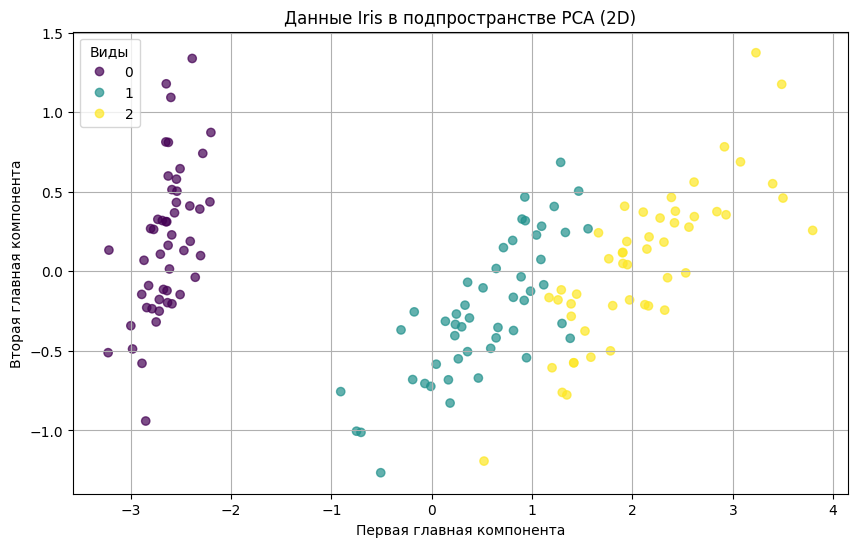

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

# Применение PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Визуализация
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.title("Данные Iris в подпространстве PCA (2D)")
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.legend(*scatter.legend_elements(), title="Виды")
plt.grid(True)
plt.show()

#### Обнаружение линейных зависимостей

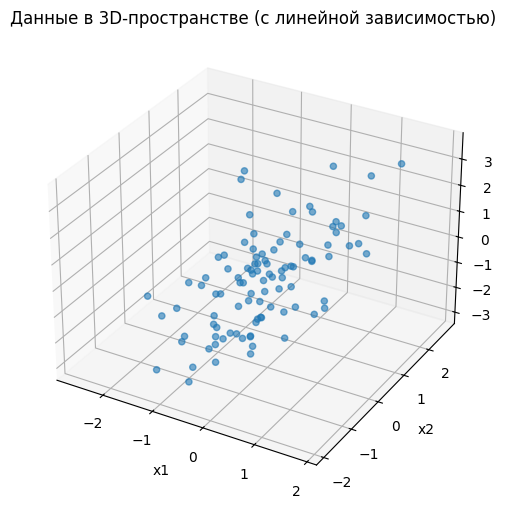

In [2]:
from mpl_toolkits.mplot3d import Axes3D

# Генерация данных
np.random.seed(42)
x1 = np.random.randn(100)
x2 = np.random.randn(100)
x3 = x1 + x2 + 0.1 * np.random.randn(100)  # С небольшим шумом

# Визуализация
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x1, x2, x3, alpha=0.6)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')
ax.set_title("Данные в 3D-пространстве (с линейной зависимостью)")
plt.show()

#### Обнаружение аномалий

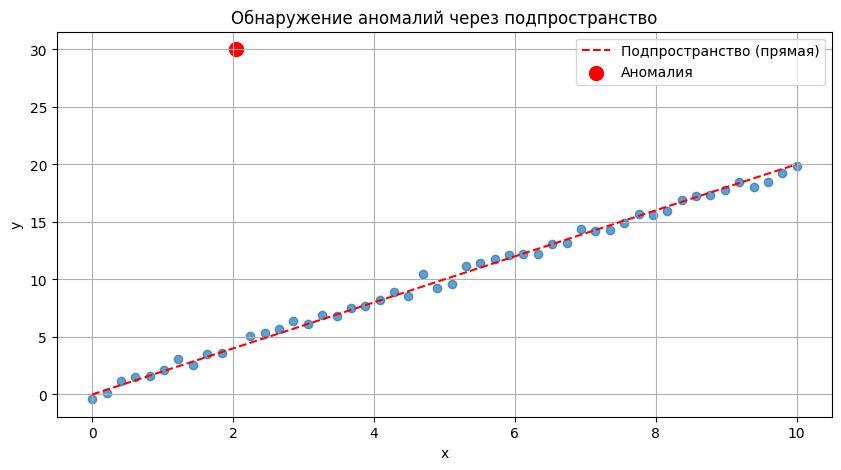

In [3]:
# Генерация данных на прямой + аномалии
x = np.linspace(0, 10, 50)
y = 2 * x + 0.5 * np.random.randn(50)
y[10] = 30  # Аномалия

# Визуализация
plt.figure(figsize=(10, 5))
plt.scatter(x, y, alpha=0.7)
plt.plot(x, 2*x, 'r--', label="Подпространство (прямая)")
plt.scatter(x[10], y[10], color='red', s=100, label="Аномалия")
plt.title("Обнаружение аномалий через подпространство")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

## Проверка результата

Для каждого множества проверка выполняется численно: берётся контрпример, нарушающий одну из аксиом подпространства, и демонстрируется, что результат не принадлежит множеству. Для множества $C$ дополнительно проверяется принадлежность нулевого вектора: при $\gamma = 0$ — принадлежит, при $\gamma = 1$ — нет. В дополнительном примере проверка качественная — через визуальный анализ графиков.

## Вывод

Понятие подпространства объединяет три важных для ML сценария: сжатие данных (PCA), обнаружение избыточности (линейная зависимость признаков) и детектирование аномалий. Аксиомы подпространства — это не формальность: они гарантируют, что линейные операции (а значит, и линейные модели) корректно работают внутри этого множества.
